## Data Description
![The Sinking of the Titanic](https://upload.wikimedia.org/wikipedia/commons/6/6e/St%C3%B6wer_Titanic.jpg)


The Titanic dataset contains information about the passengers on board the RMS Titanic, which famously sank on its maiden voyage in 1912. This dataset is a classic for data analysis, providing a mix of categorical, numerical, and text data that allows us to explore factors that influenced passenger survival.

### Columns Definitions

Below is a breakdown of the columns included in the dataset and what they represent:

| Column | Description | Key/Notes |
| :--- | :--- | :--- |
| **PassengerId** | Unique identifier for each passenger | Numerical index |
| **Survived** | Survival status | 0 = No, 1 = Yes |
| **Pclass** | Ticket class (Socio-economic status) | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Name** | Full name of the passenger | Includes titles (Mr., Mrs., etc.) |
| **Sex** | Gender of the passenger | male, female |
| **Age** | Age in years | Fractional if less than 1 |
| **SibSp** | Number of siblings or spouses aboard | Includes brothers, sisters, and partners |
| **Parch** | Number of parents or children aboard | Includes mother, father, and children |
| **Ticket** | Ticket serial number | Alphanumeric string |
| **Fare** | Passenger fare | Total cost of the ticket |
| **Cabin** | Cabin number | Often contains missing values (NaN) |
| **Embarked** | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |



In [ ]:
! pip install missingno

In [16]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
# Reading the data
df=pd.read_csv('train.csv').dropna(how='all')
display(df.head(10))
display(df.sample(5))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
224,225,1,1,"Hoyt, Mr. Frederick Maxfield",male,38.0,1,0,19943,90.0000,C93,S
130,131,0,3,"Drazenoic, Mr. Jozef",male,33.0,0,0,349241,7.8958,NaN,C
260,261,0,3,"Smith, Mr. Thomas",male,NaN,0,0,384461,7.7500,NaN,Q
673,674,1,2,"Wilhelms, Mr. Charles",male,31.0,0,0,244270,13.0000,NaN,S
169,170,0,3,"Ling, Mr. Lee",male,28.0,0,0,1601,56.4958,NaN,S


In [3]:
# do i have duplicates
print("The Number of Duplicated Rows = ",df.duplicated().sum())
print("The Number of Raws in the data = ",len(df))

The Number of Duplicated Rows =  0
The Number of Raws in the data =  891


In [4]:
# check the nulls
(df.isnull().sum()/len(df)).round(2)

PassengerId    0.00
Survived       0.00
Pclass         0.00
Name           0.00
Sex            0.00
Age            0.20
SibSp          0.00
Parch          0.00
Ticket         0.00
Fare           0.00
Cabin          0.77
Embarked       0.00
dtype: float64

In [5]:
# check the data types and resources
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# check the number of unique values in each column
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [7]:
# map values to be clear to the audiance
df['Survived']=df['Survived'].replace({0:'Died',1:'Survived'})
df['Pclass']=df["Pclass"].replace({1:"First Class",2:'Second Class',3:"Third Class"})

In [8]:
# Type Casting
df['Age']=df['Age'].astype('float32')
df['Survived']=df['Survived'].astype('category')
df['Pclass']=df['Pclass'].astype('category')
df['Embarked']=df['Embarked'].astype('category')
df['Sex']=df['Sex'].astype('category')
df['SibSp']=df['SibSp'].astype('Int8')
df['Parch']=df['Parch'].astype('Int8')

In [9]:
# the check the memory reduction
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float32 
 6   SibSp        891 non-null    Int8    
 7   Parch        891 non-null    Int8    
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: Int8(2), category(4), float32(1), float64(1), int64(1), object(3)
memory usage: 45.9+ KB


In [14]:
# remove the high cardinality columns
df.drop(['Name','PassengerId','Ticket'],axis=1,inplace=True)

In [11]:
print('Memory Reduction =',round((83.7- 45.9)/ 83.7,2))

Memory Reduction = 0.45


## Data Preparation Summary

In this phase, the dataset was cleaned and optimized for analysis. The primary focus was on assessing data integrity, handling missing values, and improving memory efficiency through proper type casting.


### 1. Data Integrity & Completeness
An initial audit was performed to ensure the quality of the 891 records:
* **Duplicates:** No duplicated rows were found, ensuring each passenger record is unique.
* **Missing Values:** A null-value analysis revealed significant gaps in specific features:
    * **Cabin:** Missing **77%** of its data, suggesting this column may need to be dropped or heavily engineered.
    * **Age:** Missing **20%** of its values, which will require imputation (e.g., using median or mean).
    * **Embarked:** Only a negligible amount of data is missing (less than 1%).

### 2. Structural Overview
The dataset consists of **12 columns** with the following distribution of unique values:
* **High Cardinality:** `PassengerId`, `Name`, and `Ticket` are unique or near-unique to each passenger.
* **Categorical:** `Survived` (2), `Sex` (2), `Pclass` (3), and `Embarked` (3).
* **Discrete Numerical:** `SibSp` and `Parch` represent family counts.

### 3. Data Transformation 
To make the data more readable and computationally efficient, the following transformations were applied:

* **Value Mapping:** * `Survived`: Converted from (0, 1) to **"Died"** and **"Survived"**.
    * `Pclass`: Converted from (1, 2, 3) to **"First Class"**, **"Second Class"**, and **"Third Class"**.
* **Type Casting:** * Categorical strings and integers were converted to the `category` and `Int8` dtypes.
    * `Age` was cast to `float32`.
* **Efficiency Gains:** These optimizations resulted in a **45% reduction** in memory usage, dropping the footprint from **83.7 KB** to approximately **45.9 KB**.

---
### 4. Optimization:
also we have dropped the high cardinality columns (those column has a unique value in each record) as PassengerId , Name and Ticket.


### Summary Table of Findings

| Step | Key Finding / Action |
| :--- | :--- |
| **Duplicates Check** | 0 duplicates found in 891 rows. |
| **Missing Data** | `Cabin` (77%) and `Age` (20%) require attention. |
| **Readability** | Mapped numeric codes to descriptive labels for `Survived` and `Pclass`. |
| **Optimization** | Achieved 45% memory reduction via downcasting and categorical types. |

<Axes: >

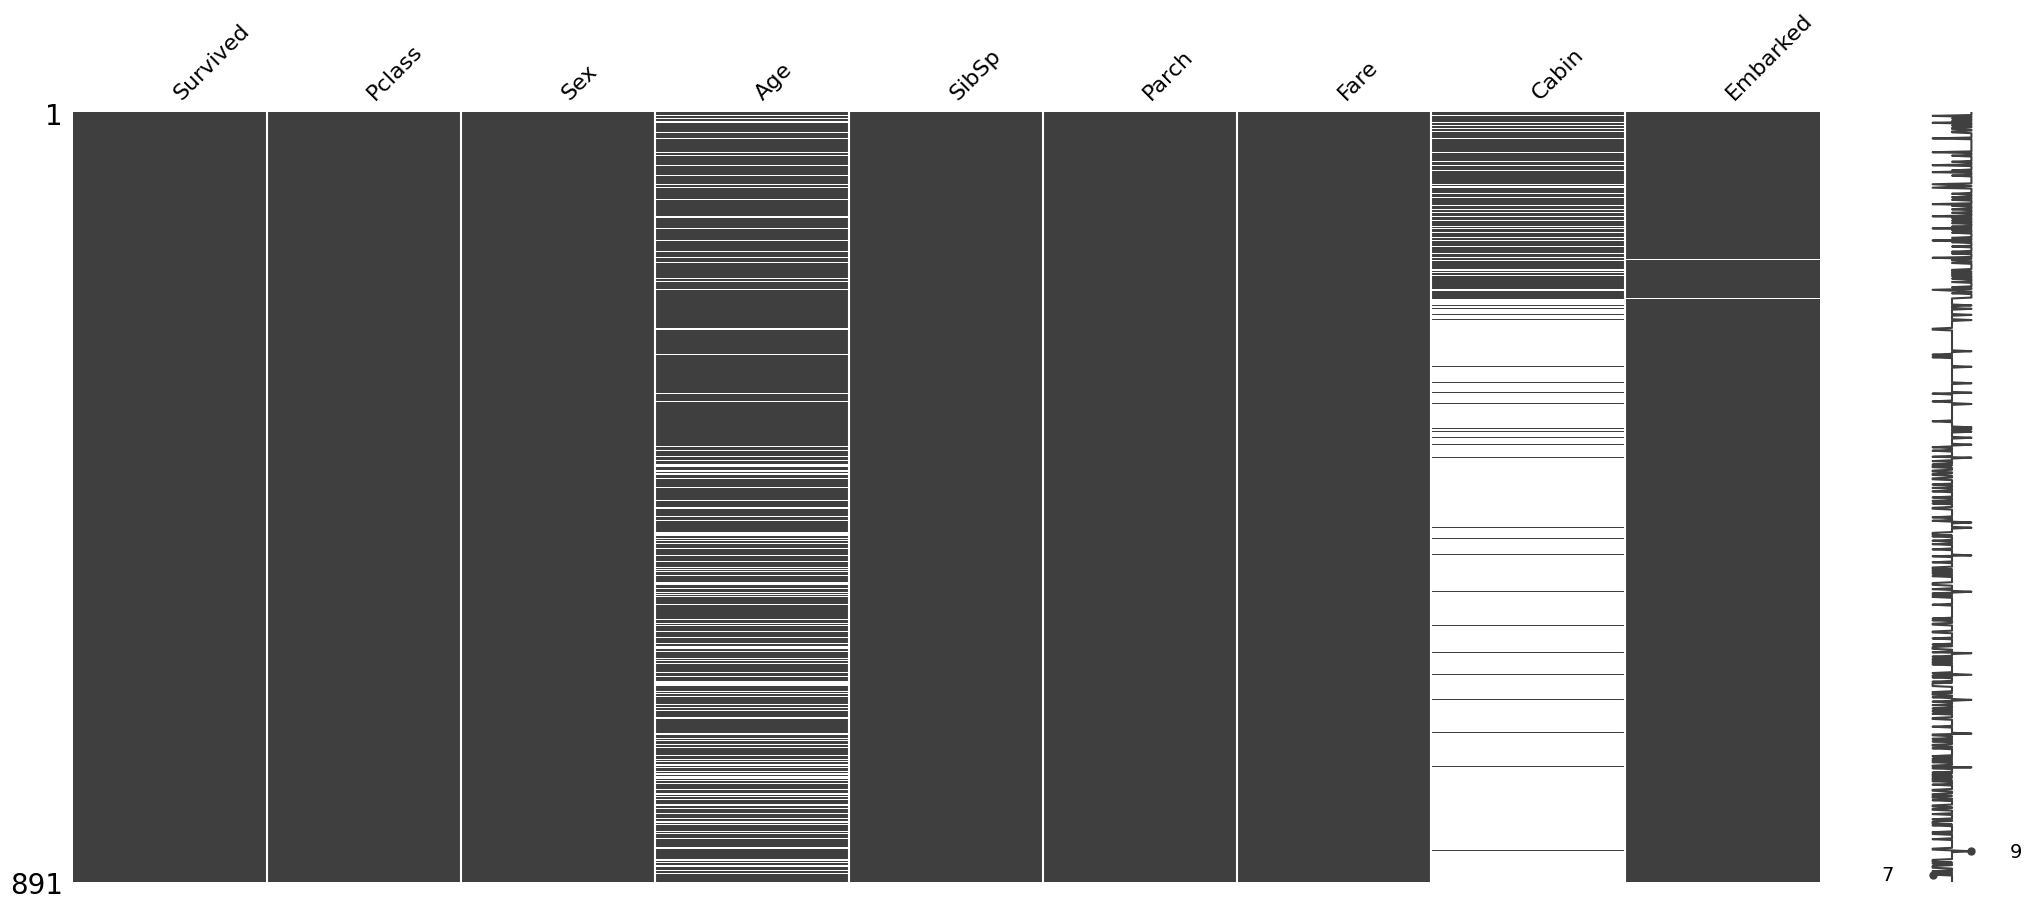

In [26]:
msno.matrix(df.sort_values('Pclass'))

### Missingness Analysis

This section outlines the strategy for handling missing values and the discovery of specific data patterns within the Titanic dataset.

####  Missing At Random (MAR) Discovery
By sorting the dataset by **Pclass** and visualizing the missing data with a nullity matrix (`msno.matrix`), a significant pattern was identified:
* **The "White Block" Effect:** Missing values in the **Cabin** column are not distributed randomly. Instead, they are heavily concentrated in the **Third Class** passenger records.
* **Interpretation:** This indicates that the data is **Missing At Random (MAR)**—the missingness of the cabin number is systematically related to the passenger's socio-economic status (Class) rather than being completely unpredictable.
